# Empirical Study

In this notebook, we study the empirical properties of the self-balancing sampler. Our main goal is to explore how the various predictability and convergence properties of the sampler depend on the parameter $\beta$. In particular, we saw that for any $c > 0$ that the limiting distribution induced by both $\beta$ and $c \beta$ is the same. Increasing $c$ makes the sampler more biased, causing it to converge faster at the cost of increased predictability. We aim to empirically quantify the trade-off between these two phenomenon. 

In [42]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

from tqdm.auto import tqdm
import os 
from pathlib import Path

workdir = Path(os.getcwd())
image_folder = workdir / 'figs'
image_folder.mkdir(exist_ok=True)

Set the relevant parameter values. Start by deciding on the relevant biases $\beta_i > 0$, and provide a list of possible scalings $c$ to compare.

In [207]:
# Parameter Values

#beta = np.ones(4)  # uniform beta
beta = np.array([1.1, 0.8, 0.9, 1.2])  # slightly non-uniform beta
beta = beta / np.linalg.norm(beta)  # normalize to unit vector

#scalings_c = [0.01, 0.05, 0.1,0.5, 1, 2] # compare c * beta for each c in scalings_c
scalings_c = np.logspace(-2, 1, num=10)  # logarithmically spaced scalings from 0.01 to 10

# number of trials and samples per trial
n_trials = 100
samples_per_trial = 10000

# Figure name conventions; save figures with path of the form image_folder/NAME_{suffix}.png
suffix = 'nonuniform'

assert np.isclose(np.sum(np.square(beta)), 1), "Beta must be a unit vector"
d = len(beta)

Define our sample probabilities and limiting distribution:

$$p_i(N) := \frac{e^{-\beta_i N_i}}{\sum_j e^{-\beta_j N_j}}, \quad p_i^* = \frac{\beta_i^{-1}}{\sum_j \beta_j^{-1}}$$

In [208]:
def p_beta(x, beta):
    '''
        Returns vector of probabilities where p_i is proportional to:
            e^{-beta x_i}
    '''
    logits = -beta * x
    logits = logits - np.max(logits)
    w = np.exp(logits)
    return w / w.sum()

def p_star(beta):
    '''
        Returns the limiting distribution p* for a given beta.
    '''
    return  (1 / beta) / np.sum(1 / beta)

Generate the given number of trials for the self-balancing sampler. For each trial, we keep track of a few running statistics:

* The total variation distance $||\mu_n - p^*||_{TV}$ from the limiting distribution after $n$ samples. 
* The "predictability": how often the sampled index is the most under-sampled one (ties broken arbitrarily).

In [209]:
# Generate samples

num_c = len(scalings_c)
# An array of all the sampled points across all trials.
samples = np.zeros((num_c, n_trials, samples_per_trial))
tv_distances = np.zeros((num_c, n_trials, samples_per_trial))
correct_predictions = np.zeros((num_c, n_trials, samples_per_trial))
expected_prediction_accuracy = np.zeros((num_c, n_trials, samples_per_trial))

p_limit = p_star(beta)

for i, c in enumerate(scalings_c):
    for trial in tqdm(range(n_trials)):

        X_n = np.zeros(d)

        for n in range(samples_per_trial):
            p = p_beta(X_n, c * beta)
            next_sample = np.random.choice(range(d), p=p)

            weighted_counts = beta * X_n
            most_undersampled = np.flatnonzero(np.isclose(weighted_counts, weighted_counts.min()))

            correct_predictions[i, trial, n] = int(next_sample in most_undersampled) / len(most_undersampled)
            expected_prediction_accuracy[i, trial, n] = p[most_undersampled].sum() / len(most_undersampled)

            X_n[next_sample] += 1
            samples[i, trial, n] = next_sample

            mu_n = X_n / (n+1)
            tv_distances[i, trial, n] = 0.5 * np.sum(np.abs(mu_n - p_limit))

fraction_correct_all = np.mean(correct_predictions, axis=2)
expected_accuracy_all = np.mean(expected_prediction_accuracy, axis=2)

# By default, estimate predictability from the tail of the run so the small-c transient
# does not dominate the comparison with the asymptotic baseline p_max^*.
predictability_tail_fraction = 0.1
predictability_start = int((1 - predictability_tail_fraction) * samples_per_trial)
fraction_correct = np.mean(correct_predictions[:, :, predictability_start:], axis=2)
expected_accuracy = np.mean(expected_prediction_accuracy[:, :, predictability_start:], axis=2)

100%|██████████| 100/100 [00:37<00:00,  2.70it/s]


### Convergence Rate

Recall that the paper proves the convergence rate is $O(n^{-1})$. We want to identify the relevant constant. Since we expect:

$$||\mu_n - p^*||_{TV} = \frac{A(\beta)}{n} + \frac{B(\beta)}{n^2} + o(n^{-2}) \to n||\mu_n - p^*||_{TV}= A - \frac{B}{n} + o(n^{-1})$$

 we can estimate $A$ by simulating enough samples for each trial until $n \cdot TV$ converges, waiting for the lower order terms to die off, and taking the asymptotic value of $n \cdot TV$. Since the limiting distribution $p^*$ is unaffected when the weights $\beta$ are scaled by some constant factor ($p^*(\beta) = p^*(c\beta)$ for any $c > 0$) we also hope to understand how this constant $A$ or any lower-order terms depends on this factor.

Let's start by just plotting $n \cdot TV$ to see this in action.

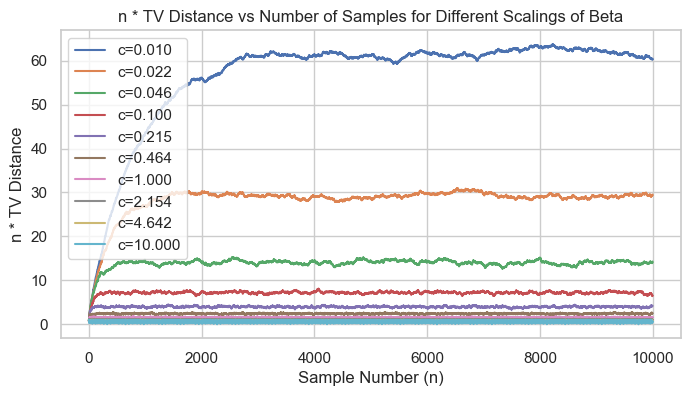

In [210]:
n = np.arange(1, tv_distances.shape[2] + 1)
scaled_tv_distances = tv_distances * n  # broadcasts over last axis
mean_tv_distances = np.mean(scaled_tv_distances, axis=1)

plt.figure(figsize=(8, 4))

for i, c in enumerate(scalings_c):
    plt.plot(mean_tv_distances[i], label=f"c={c:.3f}")

plt.title(f"n * TV Distance vs Number of Samples for Different Scalings of Beta")
plt.xlabel("Sample Number (n)")
plt.ylabel("n * TV Distance")
plt.legend()
plt.show()

We observe above that the value tends to stabilize as the lower-order terms die off. If we want to get a sense of what the leading constant is, and how it varies with $c$ as we scale $\beta$, we can plot this limiting value as a function of $c$. We do that below. Since the curves still fluctuate, we average the last few values of the process to get a more reasonable estimate of this asymptotic value.

From our analysis in the paper, we expect the behavior to be either $O(c^{-1/2})$ or $O(c^{-1})$, so to separate these two we look at the slope on a log-log plot. The former occurs when $\beta$ is uniform, and the latter when it is not. 

Beta =  [0.543 0.395 0.444 0.593]
Beta is not uniform; expect c^{-1} behavior in small c regime


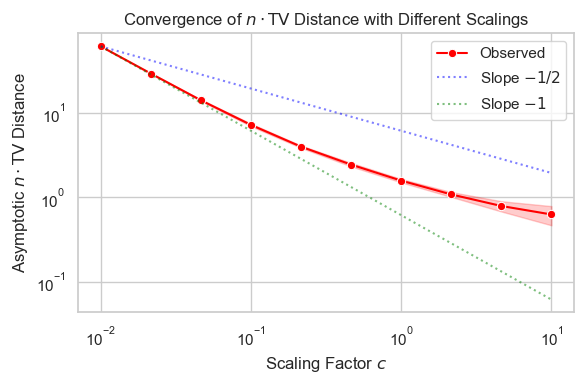

In [211]:
# fraction of values to use to estimate asymptotic TV distance
fraction_values = 0.1 

print('Beta = ', np.round(beta, 3))

if np.all(np.isclose(beta, beta[0])):
    print("Beta is uniform; expect c^{-1/2} behavior in small c regime")
else:
    print("Beta is not uniform; expect c^{-1} behavior in small c regime")

num_values = int(fraction_values * samples_per_trial)
means_conv = mean_tv_distances[:, -num_values:].mean(axis=1)
std_devs = mean_tv_distances[:, -num_values:].std(axis=1)

# reference slopes
c0 = scalings_c[0]
y0 = means_conv[0]
slope_minus_half = y0 * (scalings_c / c0) ** (-0.5)
slope_minus_one = y0 * (scalings_c / c0) ** (-1.0)

# seaborn style
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(6, 4))

# observed curve
sns.lineplot(
    x=scalings_c,
    y=means_conv,
    marker="o",
    color="red",
    label="Observed"
)

# uncertainty band
plt.fill_between(
    scalings_c,
    means_conv - std_devs,
    means_conv + std_devs,
    alpha=0.2,
    color="red"
)

# reference slope lines
sns.lineplot(
    x=scalings_c,
    y=slope_minus_half,
    linestyle=":",
    color="blue",
    alpha=0.5,
    label=r"Slope $-1/2$"
)

sns.lineplot(
    x=scalings_c,
    y=slope_minus_one,
    linestyle=":",
    color="green",
    alpha=0.5,
    label=r"Slope $-1$"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Scaling Factor $c$")
plt.ylabel(r"Asymptotic $n \cdot \mathrm{TV}$ Distance")
plt.title(r"Convergence of $n \cdot \mathrm{TV}$ Distance with Different Scalings")
plt.legend()
plt.tight_layout()

filepath = image_folder / f'convergence_plot_{suffix}.png'
plt.savefig(filepath)
plt.show()

### Predictability

We compare the predictability against our two baselines: deterministic (aka greedy) sampling and iid sampling. 

For the uniform $\beta$ case, using the former we expect roughly $\frac{H_d}{d} \approx \frac{\log(d)}{d}$ answers to be correct, where $H_d$ is the $d^{th}$ harmonic number. In the latter, we expect roughly $\frac{1}{d}$ answers to be correct.

For the non-uniform $\beta$ case, greedy sampling becomes almost more predictable, as there is often only a single index that is most under-sampled. If the $\beta_i$ differ by rational factors, then sometimes this is not the case, but otherwise it is generally true. Hence the predictability is almost one. On the other hand, for iid sampling clearly the optimal thing to do is to predict the index $i = \arg\max_\ell p_\ell^*$ that is most likely to be sampled.

Recall that in the paper we heuristically show two factors govern the predictability in the small $\beta$ regime: (i) the maximum $max_i p_i^*$ and (ii) the number of indices $k$ achieving this maximum. In particular, we showed in this small $\beta$ regime that the fraction correct is approximately:

$$\max_i p_i^* +  \sqrt{\frac{\log | I^*|}{\beta_{min} S_\beta^2}} + O(\beta), \quad S_\beta = \sum_j \beta_j^{-1}$$

at least in the regime where $|I^*|$ is large, so classical asymptotics for maximums of iid gaussians apply. In the case of uniform $\beta$, we saw this simplified to:

$$\max_i p_i^* +  \frac{\sqrt{\beta \log(d)}}{d} + O(\beta).$$

 Hence we see there are two regimes roughly: an $\Theta(\sqrt{c})$ regime that occurs when the maximum is not unique, and a $O(c)$ regime that occurs when the maximum of $p_i^*$ is unique. If:

 $$\Delta(c) := \text{fraction correct} - \max p_i^*$$

 then we can differentiate between these two regimes by plotting $\frac{\Delta(c)}{\sqrt{c}}$ and $\frac{\Delta(c)}{c}$ and seeing which converges to a nonzero limit in the small $c$ regime. 

Beta =  [0.543 0.395 0.444 0.593]
Maximum of p^* is unique; expect O(c) behavior in small c regime


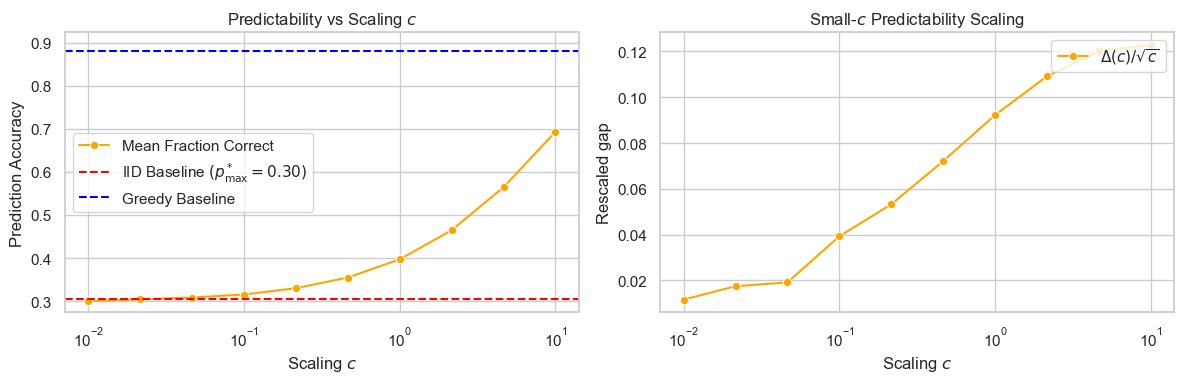

In [212]:
def harmonic_number(n):
    return np.sum(1.0 / np.arange(1, n + 1))

def deterministic_predictability(beta, T=10000):
    """
    Empirical estimate of the predictability of the greedy guessing strategy
    for a given beta.
    """
    beta = np.asarray(beta, dtype=float)
    d = len(beta)
    N = np.zeros(d, dtype=int)
    success = 0.0

    for _ in range(T):
        weighted = beta * N
        m = np.flatnonzero(np.isclose(weighted, weighted.min()))
        success += 1.0 / len(m)

        # sampler tie-breaks uniformly
        i = np.random.choice(m)
        N[i] += 1

    return success / T


print("Beta = ", np.round(beta, 3))

if np.sum(np.isclose(beta, np.min(beta))) > 1:
    print("Maximum of p^* is not unique; expect O(c^{1/2}) behavior in small c regime")
else:
    print("Maximum of p^* is unique; expect O(c) behavior in small c regime")


p_max = np.max(p_limit)
greedy_predictability = deterministic_predictability(beta)

mean_fraction_correct_all = fraction_correct_all.mean(axis=1)
mean_fraction_correct = fraction_correct.mean(axis=1)
std_fraction_correct = fraction_correct.std(axis=1)
mean_expected_accuracy = expected_accuracy.mean(axis=1)
std_expected_accuracy = expected_accuracy.std(axis=1)
delta_predictability = mean_fraction_correct - p_max


fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Axis 1: raw predictability
ax = axs[0]


sns.lineplot(
    x=scalings_c,
    y=mean_fraction_correct_all,
    color='orange',
    marker="o",
    ax=ax,
    label="Mean Fraction Correct",
)

ax.axhline(
    p_max,
    linestyle="--",
    color="red",
    label=rf"IID Baseline $(p_{{\max}}^* = {p_max:.2f})$",
)

if np.all(np.isclose(beta, beta[0])):
    ax.axhline(
        harmonic_number(d) / d,
        linestyle="--",
        color="blue",
        label="Greedy Baseline",
    )
else:
    ax.axhline(
        greedy_predictability,
        linestyle="--",
        color="blue",
        label="Greedy Baseline",
    )

ax.set_xscale("log")
ax.set_xlabel(r"Scaling $c$")
ax.set_ylabel("Prediction Accuracy")
ax.set_title(r"Predictability vs Scaling $c$")
ax.legend(loc="best")
ax.set_ylim([0.9*p_max, 1.05 * greedy_predictability])


# Axis 2: small-c scaling diagnostic
ax = axs[1]

sns.lineplot(
    x=scalings_c,
    y=delta_predictability / np.sqrt(scalings_c),
    marker="o",
    ax=ax,
    color='orange',
    label=r"$\Delta(c) / \sqrt{c}$",
)

# sns.lineplot(
#     x=scalings_c,
#     y=delta_predictability / scalings_c,
#     marker="o",
#     ax=ax,
#     label=r"$\Delta(c) / c$",
# )

ax.set_xscale("log")
ax.set_xlabel(r"Scaling $c$")
ax.set_ylabel("Rescaled gap")
ax.set_title(r"Small-$c$ Predictability Scaling")
ax.legend(loc="upper right")
plt.tight_layout()

filepath = image_folder / f'predictability_{suffix}.png'
plt.savefig(filepath)
plt.show()

### Trade-off

Now, we study the trade-off between predictability and convergence rate. Recall that the asymptotic value of $n \cdot TV$ is some measure of the coefficient $An^{-1}$ in the leading term of the average convergence rate, so it is in a sense a measure of the (inverse) convergence rate.

Beta =  [0.543 0.395 0.444 0.593]


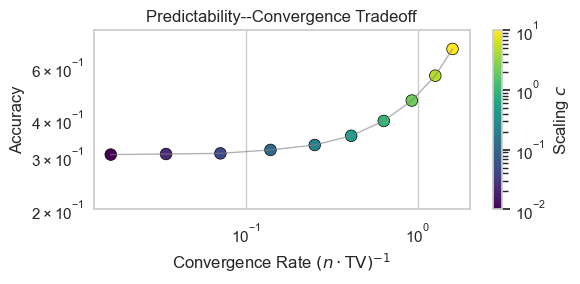

In [213]:
sns.set_theme(style="whitegrid", context="notebook")

print("Beta = ", np.round(beta, 3))

x_vals = 1 / means_conv
y_vals = mean_fraction_correct 

fig, ax = plt.subplots(figsize=(6, 3))

# Connect the points to show trajectory
ax.plot(
    x_vals,
    y_vals,
    linestyle="-",
    linewidth=1,
    alpha=0.6,
    color="gray",
)

# Color points by scaling c
norm = mpl.colors.LogNorm(vmin=np.min(scalings_c), vmax=np.max(scalings_c))
scatter = ax.scatter(
    x_vals,
    y_vals,
    c=scalings_c,
    norm=norm,
    cmap="viridis",
    s=70,
    edgecolor="black",
    linewidth=0.5,
)

# Colorbar for c values
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label(r"Scaling $c$")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Convergence Rate $(n \cdot \mathrm{TV})^{-1}$")
ax.set_ylabel("Accuracy")
ax.set_title(r"Predictability--Convergence Tradeoff")

#ax.set_ylim([p_max * 0.9, 1.1 * greedy_predictability])
ax.set_ylim([0.2, 0.8])
plt.tight_layout()

filepath = image_folder / f'tradeoff_{suffix}.png'
plt.savefig(filepath)


plt.show()

## Citizen's Assembly.

In this section, we simulate the self-balancing sampler on the citizen's assembly problem discussed in Section 13 of [Flanigan et al.](https://procaccia.info/wp-content/uploads/2021/08/assemblies.pdf). The setting is as follows:

> Say that we want to select an assembly of $k = 200$ people that includes at least $99$ of
> each category: women, men, liberals, and conservatives. Let the pool consist of $1,000$
> conservative men, $999$ liberal women, and $1$ conservative woman. 

The goal is to generate such an assemly meeting the desired quota, where each individual in the pool has a reasonable chance of being selected. Namely, we want to maximize the
minimal probability a specific individual is being sampled according to the sampling scheme, so that each individual is as fairly represented as possible. We call the latter property the *representiveness* of the scheme. 

Note that the stratified sampling algorithm that selects 100 uniformly drawn women and 100 uniformly 
drawn men satisfies the quotas and selects each pool member with equal probability $10\%$. On the other hand, the *LEGACY* algorithm discussed in [Flanigan et al.](https://procaccia.info/wp-content/uploads/2021/08/assemblies.pdf) has only a $0.2 \%$ chance of selecting the conservative woman. In particular, even though it aims to balance covariates across the assembly, it is a sense undemocratic because the rare class (conservative women) is rarely represented.

In this setting, the self-balancing sampler essentially biases samplers towards classes that are far from their desired quotas. While it cannot gaurantee the quota is met, it in a sense interpolates between two aims: the probability the quota is met and the representiveness of the sample. 

To apply the self-balancing sampler to this setting, we propose two different sequential strategies

1. **Stratified**: We choose the feature vector from $\{\text{man}, \text{woman}\} \times \{\text{conservative}, \text{liberal}\}$ using the self-balancing sampler, and then uniformly choose an individual from the given class. The relative weights $(\beta_i^{-1})_{i=1}^4$ are chosen proportional to the initial class size. This ensures at stationarity that individuals are selected uniformly at random from the total population. 

2. **Attribute-Balanced**: Each individual is given weight proportional to $\exp(-\beta_{gender} N_{gender} - \beta_{party} N_{party})$. This is akin to running two independent copies of the self-balancing sampler, one for the gender and one for the party, and then selecting an individual uniformly at random from the selected gender/party class. 

As a baseline, we additionally study the simple strategy where individuals are selected sequentially uniformly at random to be part of the assembly. We call this the *IID Uniform Baseline* below. 

For each of these proposed sampling strategies, we hope to understand
* The probability the given quotas are satisfied.
* How likely each specific individual is to be selected to be part of the assembly. In particular, what does the worst-case selection probability look like? 
* The trade-off between these two aims that varying the bias parameter induces.

For the last point of interest, we expect increasing bias to increase the probability the quota is met, as the bias parameter reduces the variance of the class sizes in the assembly. On the other hand, increasing bias likely decreases the probability rare classes are sampled, especially under sampling scheme 2 above, reducing the representiveness of the scheme. 

To get a sense of this, we simulate sampling many assemblies **without replacement** according to these two rules. Across many runs we record:

1. The gender and party margins of the final assembly.
2. Whether the assembly satisfies the quota of at least `99` in each of the four categories.
3. For each individual, the empirical probability of being selected into the assembly. We are particularly interested in the worst-case selection probability. 

Again, we are mainly interested in how these quantities vary as we vary the $\beta$ parameter. As before, we fix the baseline bias parameters $\beta$ and rerun the citizen's assembly experiment with $\beta' = c\beta$ for some range of scalings $c$. 

For each value of $c$ and each sampler, we estimate the probability that the quota is met and the worst-case probability that a specific individual is selected. For the former, we merely look at the fraction of assemblies in the simulation where the quota is met, and use that as our estimate. For the latter, we estimate the selection probability $\hat{p}_i$ for each individual using the frequency of assemblies they were present in, and then take the minimum over $i$. To generate confidence bands, we bootstrap resample from our collection of assemblies.

Note our estimate of the minimum selection probability is downwards biased, as its the minimum of a bunch of noisy estimates. More formally, consider the case of uniformly at random sampling a fraction $p$ of the $m$ total participants, and repeating this $n$ times to form $n$ assemblies. Approximating this by sampling with replacement, we see an individuals empirical selection probability is $\hat{p}_i \sim n^{-1} \mathrm{Binom}(n, p)$, while of course the true probability is $p$. Then, using the normal approximation to the binomial, the *minimum* selection probability is of order:

$$\mathbb{E} \min_{i \leq m} \hat{p}_i \approx p - \mathbb{E} \min_{i \leq m} N\left(0, \sqrt{\frac{p(1-p)}{n}} \right) \approx p - \sqrt{\frac{2p(1-p) \log(m)}{ n}}.$$

while of course at a population level the probability is just $p$, so we under-estimate by a factor of $\sqrt{\log(m) / n}$. This is why we use the IID uniform sampling baseline as a baseline for comparison, but if $n$ is chosen sufficiently large relative to $m$, then this under-estimation is negligible. 

Set relevant parameter values.

In [49]:
# Assembly size
assembly_size = 200 # k

# Class sizes
class_sizes = np.zeros((2,2), dtype=int)
class_sizes[0, 0] = 1000 # conservative men
class_sizes[0, 1] = 1 # conservative women
class_sizes[1, 0] = 0 # liberal men
class_sizes[1, 1] = 999 # liberal women

total_population = class_sizes.sum()

# Bias Parameters
base_beta_scaling = 1.0 # set initial scaling of beta parameters in stratified sampling
base_beta_gender = 1.0 # set initial bias parameters for attributed-balanced sampling
base_beta_party = 1.0

# Simulation Parameters
n_assembly_runs = 10000
assembly_c_scalings = np.logspace(-2, 1, num=10) # range of scalings c 
n_tradeoff_assembly_runs = n_assembly_runs       # size of bootstrap samples
n_worst_case_bootstrap_replicates = 500          # number of bootstrap samples

Run citizen's assembly simulation.

In [50]:
GENDER_NAMES = np.array(["man", "woman"])
PARTY_NAMES = np.array(["conservative", "liberal"])
CLASS_NAMES = np.array([
    "conservative men",
    "conservative women",
    "liberal men",
    "liberal women",
])

party_of_class = np.array([0, 0, 1, 1])
gender_of_class = np.array([0, 1, 0, 1])
flat_class_sizes = class_sizes.reshape(-1)

assert assembly_size <= total_population, "Assembly size cannot exceed the total population."

individual_class = np.repeat(np.arange(4), flat_class_sizes)
class_member_ids = [np.flatnonzero(individual_class == c) for c in range(4)]


def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    logits = logits - np.max(logits)
    weights = np.exp(logits)
    return weights / weights.sum()


def draw_from_probs(rng, probs):
    return rng.choice(len(probs), p=probs)


def summarize_margin_counts(class_counts):
    return {
        "men": int(class_counts[0] + class_counts[2]),
        "women": int(class_counts[1] + class_counts[3]),
        "conservative": int(class_counts[0] + class_counts[1]),
        "liberal": int(class_counts[2] + class_counts[3]),
    }


def quota_satisfied(class_counts, quota=99):
    margins = summarize_margin_counts(class_counts)
    return all(margins[name] >= quota for name in margins)


def run_stratified_class_sampler(rng, assembly_size, class_sizes, beta_scaling=1.0):
    """
    Run the class-level self-balancing sampler without replacement.
    The target class frequencies are based on the scaled weights
    beta_scaling * class_size / total_population, while individuals are
    still treated symmetrically within each class.
    """
    flat_sizes = class_sizes.reshape(-1)
    total_population = flat_sizes.sum()
    beta_class = np.full(4, np.inf)
    positive = flat_sizes > 0
    beta_inv = beta_scaling * flat_sizes[positive] / total_population
    beta_class[positive] = 1.0 / beta_inv

    remaining = flat_sizes.copy()
    class_counts = np.zeros(4, dtype=int)
    chosen_ids = np.empty(assembly_size, dtype=int)
    class_orders = [rng.permutation(ids) for ids in class_member_ids]
    class_ptrs = np.zeros(4, dtype=int)

    for t in range(assembly_size):
        active = np.flatnonzero(remaining > 0)
        probs = softmax(-beta_class[active] * class_counts[active])
        chosen_class = active[draw_from_probs(rng, probs)]

        chosen_ids[t] = class_orders[chosen_class][class_ptrs[chosen_class]]
        class_ptrs[chosen_class] += 1
        class_counts[chosen_class] += 1
        remaining[chosen_class] -= 1

    return chosen_ids, class_counts


def run_attribute_balanced_sampler(rng, assembly_size, class_sizes, beta_gender=1.0, beta_party=1.0):
    """
    Sample individuals without replacement using multiplicative weights built
    from the current gender and party counts in the partial assembly.
    """
    flat_sizes = class_sizes.reshape(-1)
    remaining = flat_sizes.copy()
    gender_counts = np.zeros(2, dtype=int)
    party_counts = np.zeros(2, dtype=int)
    class_counts = np.zeros(4, dtype=int)
    chosen_ids = np.empty(assembly_size, dtype=int)
    class_orders = [rng.permutation(ids) for ids in class_member_ids]
    class_ptrs = np.zeros(4, dtype=int)

    for t in range(assembly_size):
        active = np.flatnonzero(remaining > 0)
        logits = (
            np.log(remaining[active])
            - beta_gender * gender_counts[gender_of_class[active]]
            - beta_party * party_counts[party_of_class[active]]
        )
        probs = softmax(logits)
        chosen_class = active[draw_from_probs(rng, probs)]

        chosen_ids[t] = class_orders[chosen_class][class_ptrs[chosen_class]]
        class_ptrs[chosen_class] += 1
        class_counts[chosen_class] += 1
        gender_counts[gender_of_class[chosen_class]] += 1
        party_counts[party_of_class[chosen_class]] += 1
        remaining[chosen_class] -= 1

    return chosen_ids, class_counts


def bootstrap_worst_case_selection_probability(selected_ids_by_run, n_bootstrap, rng, progress=None):
    if n_bootstrap <= 0:
        return {
            "worst_case_bootstrap_mean": np.nan,
            "worst_case_bootstrap_se": np.nan,
            "worst_case_bootstrap_lower": np.nan,
            "worst_case_bootstrap_upper": np.nan,
        }

    n_runs = selected_ids_by_run.shape[0]
    bootstrap_values = np.empty(n_bootstrap)

    for b in range(n_bootstrap):
        sampled_runs = rng.integers(0, n_runs, size=n_runs)
        bootstrap_counts = np.bincount(
            selected_ids_by_run[sampled_runs].ravel(),
            minlength=total_population,
        )
        bootstrap_values[b] = bootstrap_counts.min() / n_runs
        if progress is not None:
            progress.update(1)

    return {
        "worst_case_bootstrap_mean": bootstrap_values.mean(),
        "worst_case_bootstrap_se": bootstrap_values.std(ddof=1) if n_bootstrap > 1 else 0.0,
        "worst_case_bootstrap_lower": np.quantile(bootstrap_values, 0.025),
        "worst_case_bootstrap_upper": np.quantile(bootstrap_values, 0.975),
    }


def run_citizen_assembly_scaling_experiment(c_scalings, n_runs, n_bootstrap=100, rng_seed=20260608):
    rng = np.random.default_rng(rng_seed)
    records = []
    individual_probability_frames = []
    class_probability_frames = []

    total_steps = len(c_scalings) * 2 * (n_runs + n_bootstrap)
    progress = tqdm(total=total_steps, desc="Citizen assembly scaling")

    for c in c_scalings:
        sampler_specs = {
            "Stratified self-balancing over classes": lambda rng, c=c: run_stratified_class_sampler(
                rng,
                assembly_size=assembly_size,
                class_sizes=class_sizes,
                beta_scaling=base_beta_scaling / c,
            ),
            "Attribute-balanced individual sampler": lambda rng, c=c: run_attribute_balanced_sampler(
                rng,
                assembly_size=assembly_size,
                class_sizes=class_sizes,
                beta_gender=c * base_beta_gender,
                beta_party=c * base_beta_party,
            ),
        }

        for rule_name, sampler in sampler_specs.items():
            selected_count_by_individual = np.zeros(total_population, dtype=int)
            selected_ids_by_run = np.empty((n_runs, assembly_size), dtype=np.int32)
            quota_hits = 0

            progress.set_postfix(c=f"{c:.3g}", sampler=rule_name[:24])

            for run_idx in range(n_runs):
                selected_ids, class_counts = sampler(rng)
                selected_ids_by_run[run_idx] = selected_ids
                selected_count_by_individual[selected_ids] += 1
                quota_hits += quota_satisfied(class_counts)
                progress.update(1)

            individual_selection_prob = selected_count_by_individual / n_runs
            worst_individual_idx = int(np.argmin(individual_selection_prob))
            worst_class_idx = int(individual_class[worst_individual_idx])
            quota_prob = quota_hits / n_runs
            progress.set_postfix(c=f"{c:.3g}", sampler=rule_name[:24], stage="bootstrap")
            bootstrap_summary = bootstrap_worst_case_selection_probability(
                selected_ids_by_run,
                n_bootstrap,
                rng,
                progress=progress,
            )

            records.append({
                "rule": rule_name,
                "c": c,
                "quota_met_probability": quota_prob,
                "quota_met_se": np.sqrt(quota_prob * (1 - quota_prob) / n_runs),
                "worst_case_individual_probability": individual_selection_prob[worst_individual_idx],
                "worst_case_individual_id": worst_individual_idx,
                "worst_case_class": CLASS_NAMES[worst_class_idx],
                "baseline_uniform_probability": assembly_size / total_population,
                **bootstrap_summary,
            })

            individual_probability_frame = pd.DataFrame({
                "rule": rule_name,
                "c": c,
                "individual_id": np.arange(total_population),
                "class": CLASS_NAMES[individual_class],
                "gender": GENDER_NAMES[gender_of_class[individual_class]],
                "party": PARTY_NAMES[party_of_class[individual_class]],
                "estimated_selection_probability": individual_selection_prob,
            })
            individual_probability_frames.append(individual_probability_frame)

            class_probability_frame = individual_probability_frame.groupby(
                ["rule", "c", "class", "gender", "party"],
                as_index=False,
            )["estimated_selection_probability"].agg(["min", "mean", "max"])
            class_probability_frame["class_size"] = class_probability_frame["class"].map(
                dict(zip(CLASS_NAMES, flat_class_sizes))
            )
            class_probability_frames.append(class_probability_frame)

    progress.close()

    return (
        pd.DataFrame(records),
        pd.concat(individual_probability_frames, ignore_index=True),
        pd.concat(class_probability_frames, ignore_index=True),
    )

def run_iid_uniform_assembly_baseline(n_runs, n_bootstrap=100, rng_seed=20260609):
    rng = np.random.default_rng(rng_seed)
    selected_ids_by_run = np.empty((n_runs, assembly_size), dtype=np.int32)
    selected_count_by_individual = np.zeros(total_population, dtype=int)
    quota_hits = 0

    total_steps = n_runs + n_bootstrap
    progress = tqdm(total=total_steps, desc="IID uniform assembly baseline")

    for run_idx in range(n_runs):
        selected_ids = rng.choice(total_population, size=assembly_size, replace=False)
        class_counts = np.bincount(individual_class[selected_ids], minlength=4)
        selected_ids_by_run[run_idx] = selected_ids
        selected_count_by_individual[selected_ids] += 1
        quota_hits += quota_satisfied(class_counts)
        progress.update(1)

    individual_selection_prob = selected_count_by_individual / n_runs
    worst_individual_idx = int(np.argmin(individual_selection_prob))
    worst_class_idx = int(individual_class[worst_individual_idx])
    quota_prob = quota_hits / n_runs

    progress.set_postfix(stage="bootstrap")
    bootstrap_summary = bootstrap_worst_case_selection_probability(
        selected_ids_by_run,
        n_bootstrap,
        rng,
        progress=progress,
    )
    progress.close()

    baseline = {
        "rule": "IID uniform assembly baseline",
        "quota_met_probability": quota_prob,
        "quota_met_se": np.sqrt(quota_prob * (1 - quota_prob) / n_runs),
        "worst_case_individual_probability": individual_selection_prob[worst_individual_idx],
        "worst_case_individual_id": worst_individual_idx,
        "worst_case_class": CLASS_NAMES[worst_class_idx],
        "baseline_uniform_probability": assembly_size / total_population,
        **bootstrap_summary,
    }

    individual_probability_frame = pd.DataFrame({
        "rule": baseline["rule"],
        "individual_id": np.arange(total_population),
        "class": CLASS_NAMES[individual_class],
        "gender": GENDER_NAMES[gender_of_class[individual_class]],
        "party": PARTY_NAMES[party_of_class[individual_class]],
        "estimated_selection_probability": individual_selection_prob,
    })

    return baseline, individual_probability_frame



In [51]:
citizen_tradeoff_results, citizen_tradeoff_individual_probabilities, citizen_tradeoff_class_probabilities = run_citizen_assembly_scaling_experiment(
    assembly_c_scalings,
    n_tradeoff_assembly_runs,
    n_bootstrap=n_worst_case_bootstrap_replicates,
)

citizen_iid_baseline, citizen_iid_individual_probabilities = run_iid_uniform_assembly_baseline(
    n_tradeoff_assembly_runs,
    n_bootstrap=n_worst_case_bootstrap_replicates,
)


Citizen assembly scaling:   0%|          | 0/210000 [00:00<?, ?it/s]

IID uniform assembly baseline:   0%|          | 0/10500 [00:00<?, ?it/s]

Plot the quota-met probability and representiveness as a function of the bias scaling $c$. 

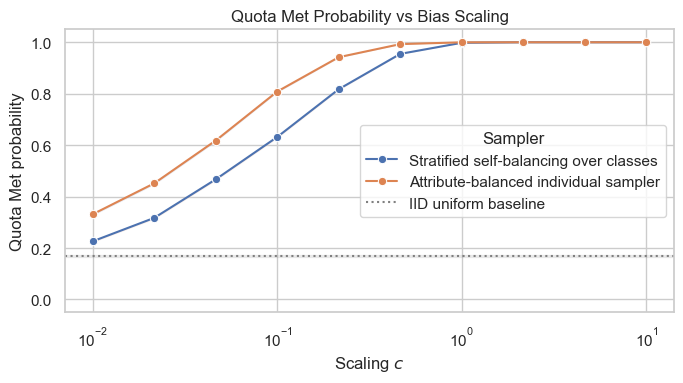

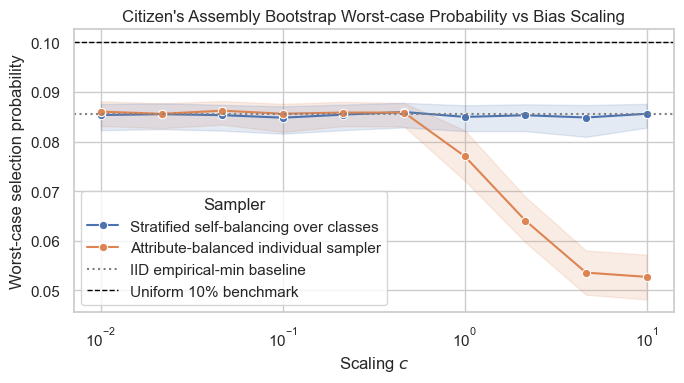

In [ ]:
# Quota Probability Plots #############
fig, ax = plt.subplots(figsize=(7, 4))

sns.lineplot(
    data=citizen_tradeoff_results,
    x="c",
    y="quota_met_probability",
    hue="rule",
    marker="o",
    errorbar=None,
    ax=ax,
)

for rule_name, subset in citizen_tradeoff_results.groupby("rule"):
    subset = subset.sort_values("c")
    ax.fill_between(
        subset["c"],
        subset["quota_met_probability"] - subset["quota_met_se"],
        subset["quota_met_probability"] + subset["quota_met_se"],
        alpha=0.15,
    )

ax.axhspan(
    citizen_iid_baseline["quota_met_probability"] - citizen_iid_baseline["quota_met_se"],
    citizen_iid_baseline["quota_met_probability"] + citizen_iid_baseline["quota_met_se"],
    color="gray",
    alpha=0.12,
)
ax.axhline(
    citizen_iid_baseline["quota_met_probability"],
    linestyle=":",
    color="gray",
    linewidth=1.5,
    label="IID uniform baseline",
)

ax.set_xscale("log")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel(r"Scaling $c$")
ax.set_ylabel("Quota Met probability")
ax.set_title("Quota Met Probability vs Bias Scaling")
ax.legend(title="Sampler")
plt.tight_layout()

filepath = image_folder / "citizen_assembly_quota_vs_scaling.png"
plt.savefig(filepath)
plt.show()



# Worst-Case Selection Prob Plots %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
fig, ax = plt.subplots(figsize=(7, 4))

rules = citizen_tradeoff_results["rule"].unique()
palette = dict(zip(rules, sns.color_palette(n_colors=len(rules))))

# add mean effect
sns.lineplot(
    data=citizen_tradeoff_results,
    x="c",
    y="worst_case_bootstrap_mean",
    hue="rule",
    palette=palette,
    marker="o",
    errorbar=None,
    ax=ax,
)

# Add bootstrap confidence bands
for rule_name, subset in citizen_tradeoff_results.groupby("rule"):
    subset = subset.sort_values("c")

    ax.fill_between(
        subset["c"],
        subset["worst_case_bootstrap_lower"],
        subset["worst_case_bootstrap_upper"],
        color=palette[rule_name],
        alpha=0.15,
    )

## Plot IID Baseline results
# ax.axhspan(
#     citizen_iid_baseline["worst_case_bootstrap_lower"],
#     citizen_iid_baseline["worst_case_bootstrap_upper"],
#     color="gray",
#     alpha=0.12,
# )
ax.axhline(
    citizen_iid_baseline["worst_case_bootstrap_mean"],
    linestyle=":",
    color="gray",
    linewidth=1.5,
    label="IID empirical-min baseline",
)

# Plot true population baseline
ax.axhline(
    assembly_size / total_population,
    linestyle="--",
    color="black",
    linewidth=1,
    label="Uniform 10% benchmark",
)

# Set plot features
ax.set_xscale("log")
ax.set_xlabel(r"Scaling $c$")
ax.set_ylabel("Worst-case selection probability")
ax.set_title("Citizen's Assembly Bootstrap Worst-case Probability vs Bias Scaling")
ax.legend(title="Sampler")
plt.tight_layout()

# Save figure
filepath = image_folder / "citizen_assembly_worst_case_vs_scaling.png"
plt.savefig(filepath)
plt.show()


Plot trade-off between quota-met probability and representiveness. 

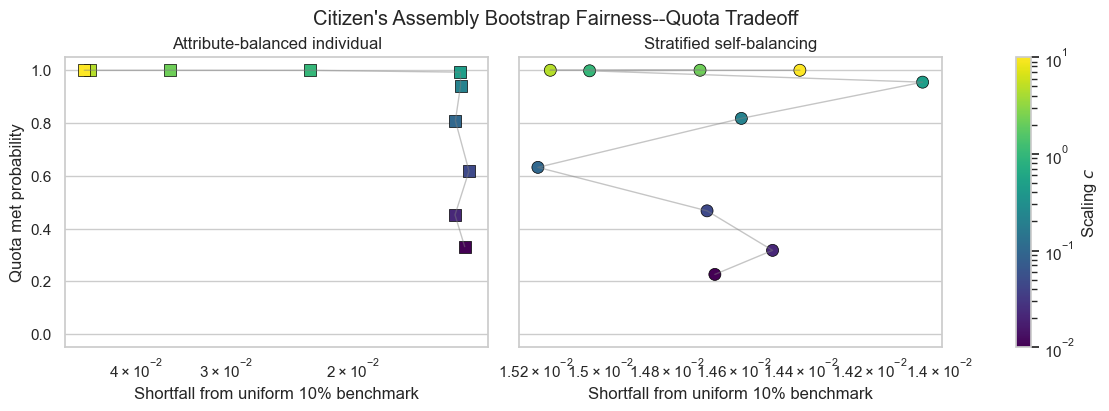

In [58]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4),
    sharey=True,
    constrained_layout=True,
)

tradeoff_plot_data = citizen_tradeoff_results.copy()
shortfall_floor = 1 / (n_tradeoff_assembly_runs * total_population)

tradeoff_plot_data["uniform_shortfall"] = np.maximum(
    assembly_size / total_population - tradeoff_plot_data["worst_case_bootstrap_mean"],
    shortfall_floor,
)
tradeoff_plot_data["uniform_shortfall_lower"] = np.maximum(
    assembly_size / total_population - tradeoff_plot_data["worst_case_bootstrap_upper"],
    shortfall_floor,
)
tradeoff_plot_data["uniform_shortfall_upper"] = np.maximum(
    assembly_size / total_population - tradeoff_plot_data["worst_case_bootstrap_lower"],
    shortfall_floor,
)

norm = mpl.colors.LogNorm(
    vmin=np.min(tradeoff_plot_data["c"]),
    vmax=np.max(tradeoff_plot_data["c"]),
)

markers = {
    "Stratified self-balancing over classes": "o",
    "Attribute-balanced individual sampler": "s",
}

rule_titles = {
    "Stratified self-balancing over classes": "Stratified self-balancing",
    "Attribute-balanced individual sampler": "Attribute-balanced individual",
}

for ax, (rule_name, subset) in zip(axes, tradeoff_plot_data.groupby("rule")):
    subset = subset.sort_values("c")

    ax.plot(
        subset["uniform_shortfall"],
        subset["quota_met_probability"],
        linestyle="-",
        linewidth=1,
        alpha=0.45,
        color="gray",
    )

    ax.scatter(
        subset["uniform_shortfall"],
        subset["quota_met_probability"],
        c=subset["c"],
        norm=norm,
        cmap="viridis",
        marker=markers[rule_name],
        s=75,
        edgecolor="black",
        linewidth=0.5,
    )

    # Optional error bars
    # xerr_lower_endpoint = np.minimum.reduce([
    #     subset["uniform_shortfall"],
    #     subset["uniform_shortfall_lower"],
    #     subset["uniform_shortfall_upper"],
    # ])
    # xerr_upper_endpoint = np.maximum.reduce([
    #     subset["uniform_shortfall"],
    #     subset["uniform_shortfall_lower"],
    #     subset["uniform_shortfall_upper"],
    # ])
    # xerr = np.vstack([
    #     subset["uniform_shortfall"] - xerr_lower_endpoint,
    #     xerr_upper_endpoint - subset["uniform_shortfall"],
    # ])
    # yerr = subset["quota_met_se"]
    # ax.errorbar(
    #     subset["uniform_shortfall"],
    #     subset["quota_met_probability"],
    #     xerr=xerr,
    #     yerr=yerr,
    #     fmt="none",
    #     ecolor="black",
    #     elinewidth=0.8,
    #     capsize=2,
    #     alpha=0.45,
    # )

    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_title(rule_titles.get(rule_name, rule_name))
    ax.set_xlabel("Shortfall from uniform 10% benchmark")
    ax.set_ylim(-0.05, 1.05)
    

axes[0].set_ylabel("Quota met probability")

fig.suptitle("Citizen's Assembly Bootstrap Fairness--Quota Tradeoff")

cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap="viridis"),
    ax=axes,
    location="right",
)
cbar.set_label(r"Scaling $c$")

filepath = image_folder / "citizen_assembly_tradeoff_side_by_side.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
plt.show()
